---

# <span style="color:#1F4E79;">Fundamentals of Underwater Acoustics and Optical Systems</span>
### <span style="color:#2E86AB;">Lecture 1 · Ocean Observatories</span>

---

## <span style="color:#1F4E79;">Table of Contents</span>
- [Part 1: Ocean Observatories (Lecture Questions)](#Part-1:-Ocean-Observatories-(Lecture-Questions))
- [Part 2: Speed of Sound](#Part-2:-Speed-of-Sound)

---

In [2]:
# Import necessary libraries
import sympy as sp
import math
import numpy as np
import matplotlib.pyplot as plt
import gsw

# Part 1: Ocean Observatories (Lecture Questions)

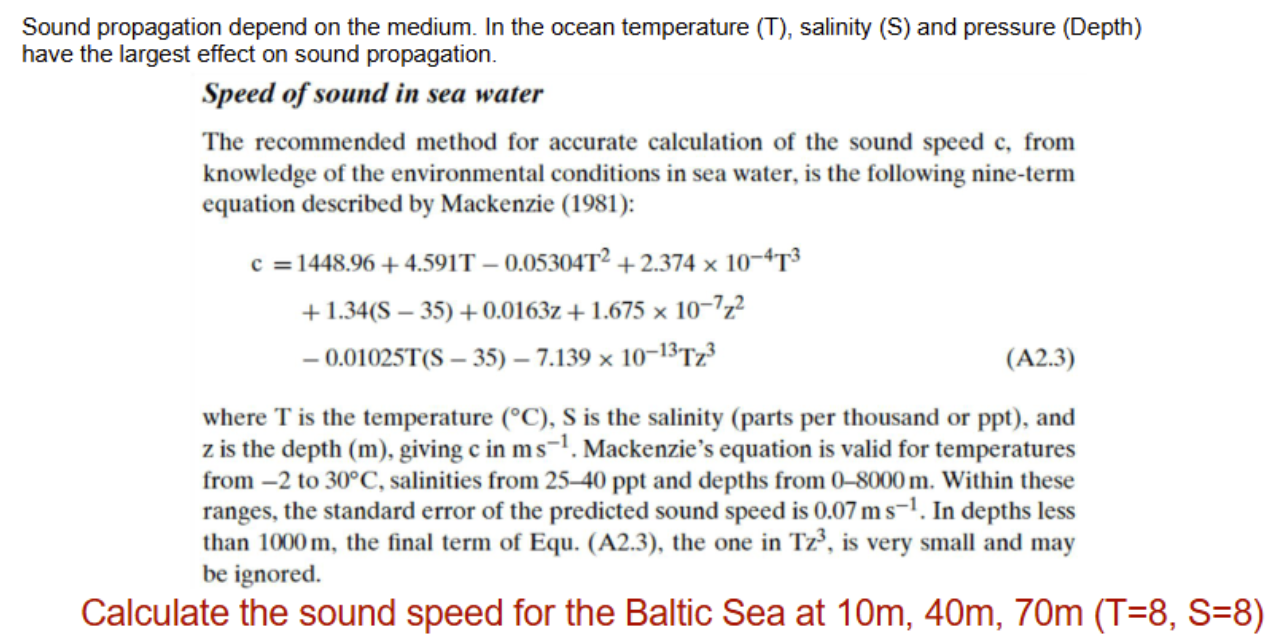

In [2]:
def speed_of_sound_in_water(temperature_celsius, salinity_ppt, depth_meters):
    """Calculate the speed of sound in seawater using the Mackenzie formula."""
    c = (1448.96 +
         4.591 * temperature_celsius -
         0.05304 * temperature_celsius**2 +
         2.374 * 10**-4 * temperature_celsius**3 +
         1.34 * (salinity_ppt - 35) +
         0.0163 * depth_meters + 
         1.675 * 10**-7 * depth_meters**2 -
         0.01025 * temperature_celsius * (salinity_ppt - 35) -
         7.139 * 10**-13 * temperature_celsius * depth_meters**3)
    return c

# Calculations for specific conditions
depths = [10, 40, 70]
speeds = [speed_of_sound_in_water(8, 8, d) for d in depths]

# Print the results
for d, s in zip(depths, speeds):
    print(f"Depth: {d} m, Speed of Sound: {s:.2f} m/s")

Depth: 10 m, Speed of Sound: 1448.61 m/s
Depth: 40 m, Speed of Sound: 1449.10 m/s
Depth: 70 m, Speed of Sound: 1449.59 m/s


# Part 2: Speed of Sound

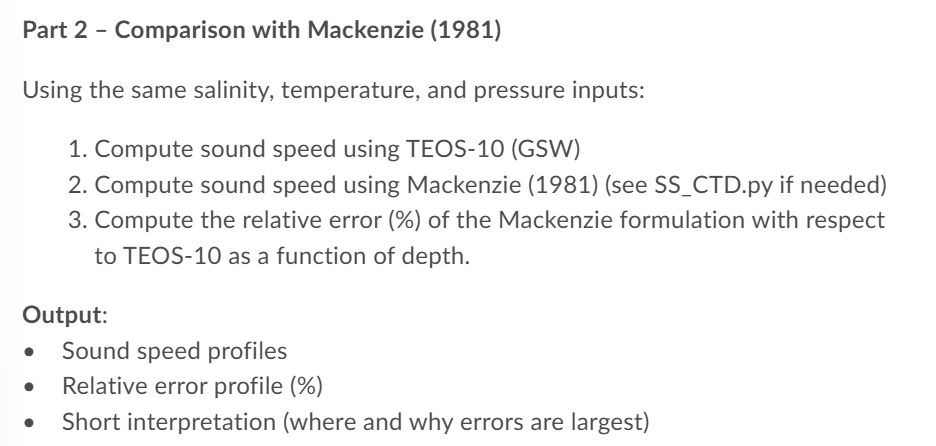

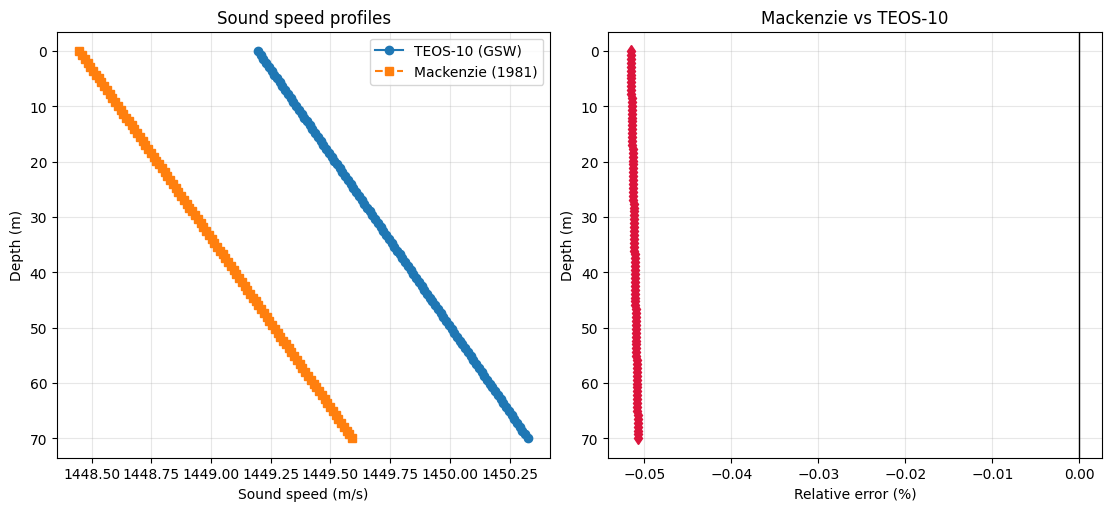


Interpretation:
Largest mismatch is at ~0.0 m with relative error -0.0516%. Errors are generally small over this shallow range, and differences come from Mackenzie being an empirical polynomial (limited calibration range) while TEOS-10 uses thermodynamically consistent seawater properties.


In [ ]:
# Reuse Part 1 inputs (same salinity, temperature, and depth-derived pressure).
T = 8.0   # in-situ temperature [deg C]
SP = 8.0  # Practical Salinity [psu]
lat = 0.0
lon = 0.0

# Initialize depth array
z = np.linspace(0, 70, 100)

# Pressure from depth (TEOS-10 convention: z is negative below sea surface).
p = gsw.p_from_z(-z, lat)  # [dbar]

# TEOS-10 sound speed
SA = gsw.SA_from_SP(SP * np.ones_like(p), p, lon * np.ones_like(p), lat * np.ones_like(p))
CT = gsw.CT_from_t(SA, T * np.ones_like(p), p)
c_teos = gsw.sound_speed(SA, CT, p)

# Mackenzie (1981) using the same depth points
c_mack = (
    1448.96
    + 4.591 * T
    - 0.05304 * T**2
    + 2.374e-4 * T**3
    + 1.34 * (SP - 35.0)
    + 0.0163 * z
    + 1.675e-7 * z**2
    - 0.01025 * T * (SP - 35.0)
    - 7.139e-13 * T * z**3
)

# Relative error of Mackenzie with respect to TEOS-10
rel_err = 100.0 * (c_mack - c_teos) / c_teos

# Plot profiles
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

axes[0].plot(c_teos, z, 'o-', label='TEOS-10 (GSW)')
axes[0].plot(c_mack, z, 's--', label='Mackenzie (1981)')
axes[0].invert_yaxis()
axes[0].set_xlabel('Sound speed (m/s)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Sound speed profiles')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(rel_err, z, 'd-', color='crimson')
axes[1].axvline(0.0, color='k', linewidth=1)
axes[1].invert_yaxis()
axes[1].set_xlabel('Relative error (%)')
axes[1].set_ylabel('Depth (m)')
axes[1].set_title('Mackenzie vs TEOS-10')
axes[1].grid(True, alpha=0.3)

plt.show()

# Short interpretation
i_max = int(np.argmax(np.abs(rel_err)))
print("\nInterpretation:")
print(
    f"Largest mismatch is at ~{z[i_max]:.1f} m with relative error {rel_err[i_max]:.4f}%. "
    "Errors are generally small over this shallow range, and differences come from "
    "Mackenzie being an empirical polynomial (limited calibration range) while TEOS-10 "
    "uses thermodynamically consistent seawater properties."
)

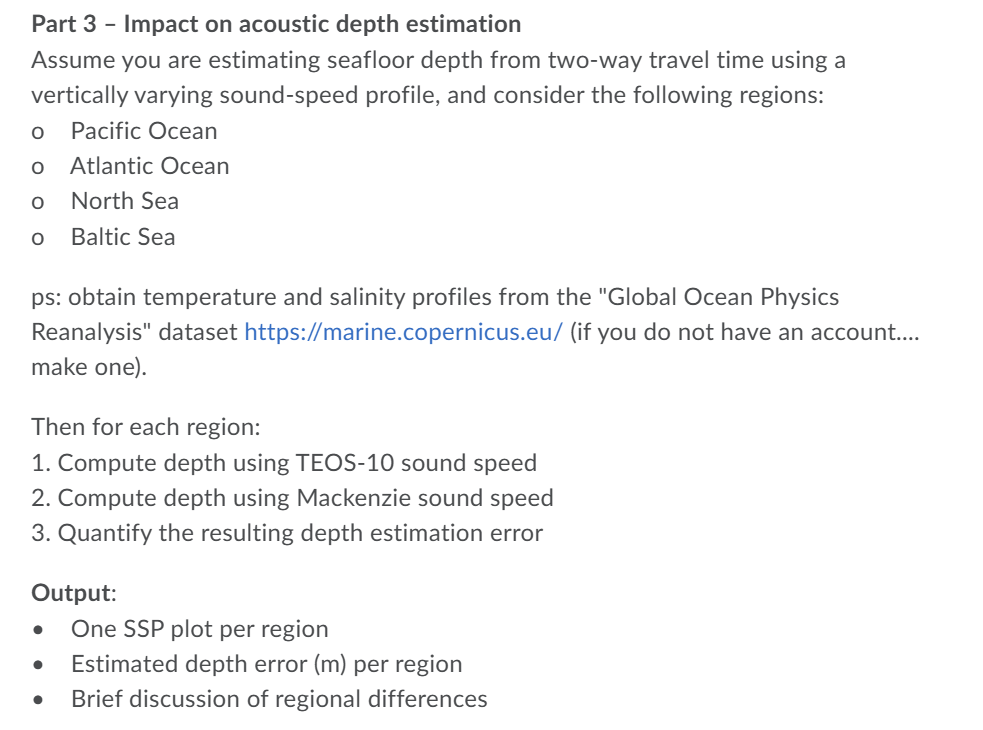

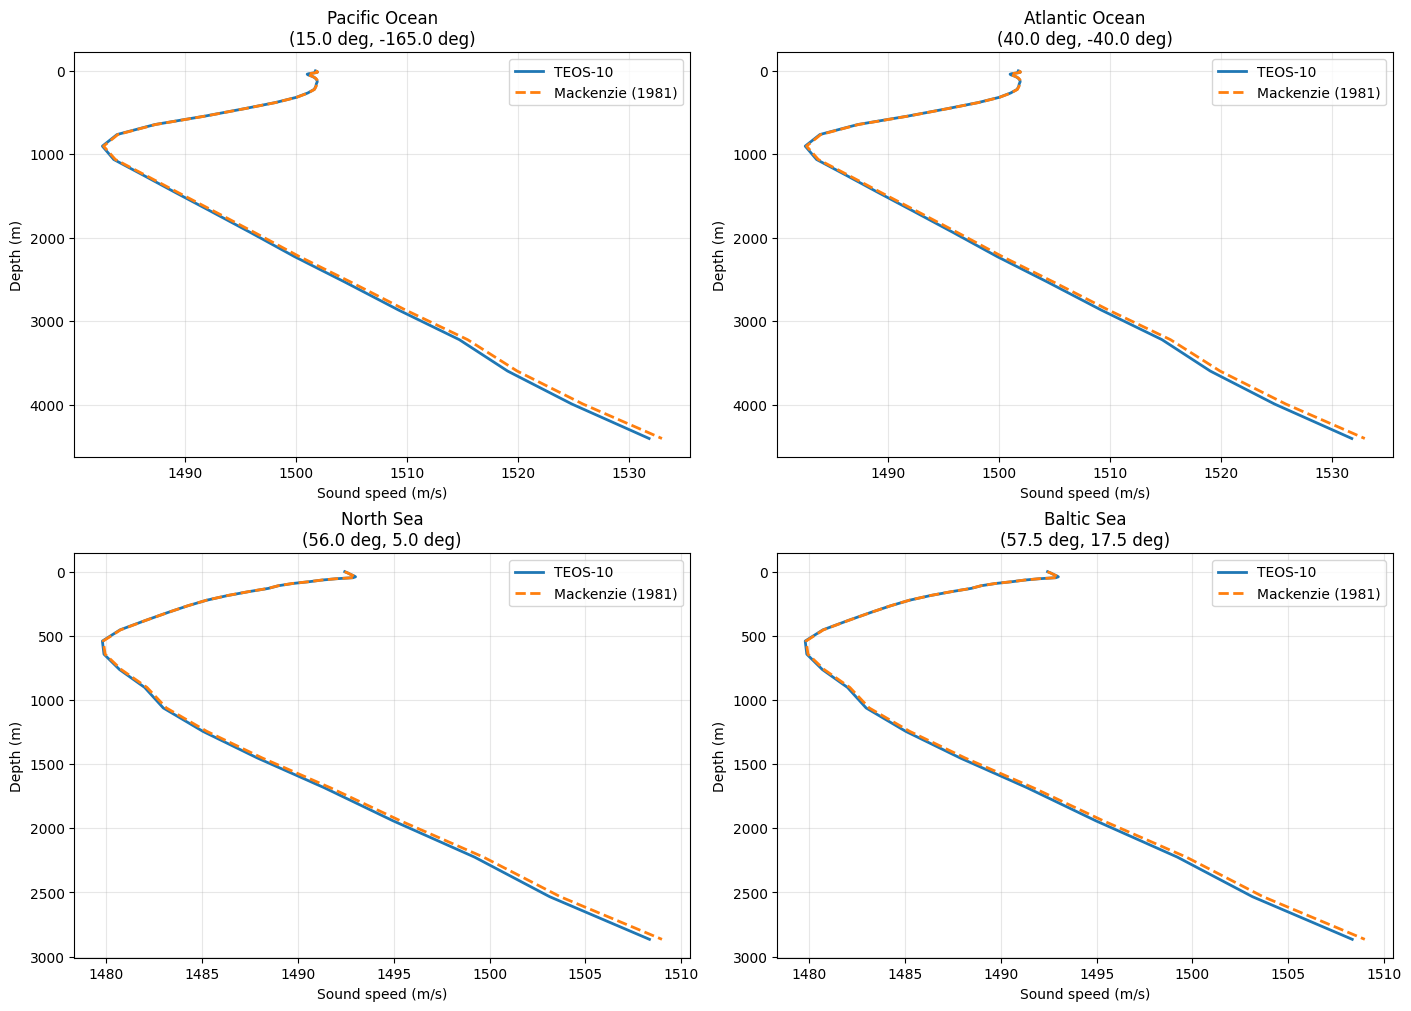

Estimated seafloor depth (TWT = 3.00 s)
Region | Depth TEOS-10 (m) | Depth Mackenzie (m) | Error Mack-TEOS (m)
Pacific Ocean |           2238.52 |            2238.79 |               0.27
Atlantic Ocean |           2238.50 |            2238.79 |               0.29
North Sea     |           2231.23 |            2231.51 |               0.28
Baltic Sea    |           2231.22 |            2231.51 |               0.28


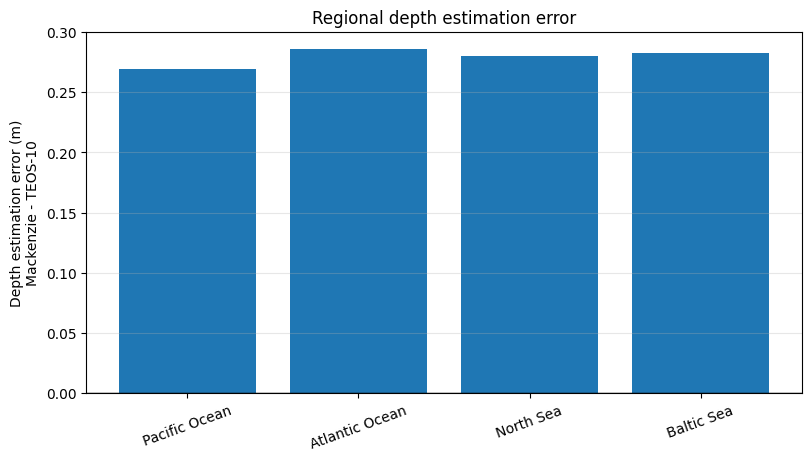


Brief discussion:
Largest absolute error appears in Atlantic Ocean (0.29 m), while the smallest is in Pacific Ocean (0.27 m).
Regional differences come from temperature/salinity stratification and salinity regime. Mackenzie is empirical, while TEOS-10 is thermodynamic, so departures increase where local hydrography is furthest from empirical-fit conditions.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import gsw
import xarray as xr

# Assumed measured two-way travel time from echosounder [s]
TWT_seconds = 3.0

# Load oceanographic data
# If file is elsewhere, set the absolute path.
ds = xr.load_dataset("NA_TS_P1D-d230605.nc")

# One representative point per region
regions = {
    "Pacific Ocean": {"lat": 15.0, "lon": -165.0},
    "Atlantic Ocean": {"lat": 40.0, "lon": -40.0},
    "North Sea": {"lat": 56.0, "lon": 5.0},
    "Baltic Sea": {"lat": 57.5, "lon": 17.5},
}


def mackenzie_1981(T, S, z):
    """Mackenzie (1981) sound speed [m/s]."""
    return (
        1448.96
        + 4.591 * T
        - 0.05304 * T**2
        + 2.374e-4 * T**3
        + 1.34 * (S - 35.0)
        + 0.0163 * z
        + 1.675e-7 * z**2
        - 0.01025 * T * (S - 35.0)
        - 7.139e-13 * T * z**3
    )


def depth_from_twt(sound_speed, depth_levels, twt):
    """Estimate seafloor depth from TWT using layered, vertically varying SSP."""
    dz = np.diff(depth_levels)
    c_avg = 0.5 * (sound_speed[:-1] + sound_speed[1:])
    twt_cumulative = np.cumsum(2.0 * dz / c_avg)

    if len(twt_cumulative) == 0:
        return np.nan
    if twt > twt_cumulative[-1]:
        return float(depth_levels[-1])

    return float(np.interp(twt, twt_cumulative, depth_levels[1:]))


results = {}

for name, coords in regions.items():
    lat_i = coords["lat"]
    lon_i = coords["lon"]

    try:
        T = ds["thetao"].isel(time=0).sel(latitude=lat_i, longitude=lon_i, method="nearest").values
        S = ds["so"].isel(time=0).sel(latitude=lat_i, longitude=lon_i, method="nearest").values
        z = ds["depth"].values

        mask = np.isfinite(T) & np.isfinite(S) & np.isfinite(z)
        T = np.asarray(T[mask], dtype=float)
        S = np.asarray(S[mask], dtype=float)
        z = np.asarray(z[mask], dtype=float)

        if len(z) < 2:
            print(f"{name}: skipped (insufficient valid profile points)")
            continue

        # Approximation often used in exercises: 1 dbar ~ 1 m
        p = z

        SA = gsw.SA_from_SP(S, p, lon_i * np.ones_like(p), lat_i * np.ones_like(p))
        CT = gsw.CT_from_t(SA, T, p)
        c_teos = gsw.sound_speed(SA, CT, p)
        c_mack = mackenzie_1981(T, S, z)

        depth_teos = depth_from_twt(c_teos, z, TWT_seconds)
        depth_mack = depth_from_twt(c_mack, z, TWT_seconds)
        depth_err = depth_mack - depth_teos

        results[name] = {
            "c_teos": c_teos,
            "c_mack": c_mack,
            "z": z,
            "lat": lat_i,
            "lon": lon_i,
            "depth_teos": depth_teos,
            "depth_mack": depth_mack,
            "depth_err": depth_err,
        }

    except Exception as e:
        print(f"{name}: failed -> {e}")


if not results:
    raise RuntimeError("No region was processed. Check file path and dataset variables.")

# 1) One SSP plot per region
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

i = -1
for i, (name, data) in enumerate(results.items()):
    ax = axes[i]
    ax.plot(data["c_teos"], data["z"], "-", lw=2, label="TEOS-10")
    ax.plot(data["c_mack"], data["z"], "--", lw=2, label="Mackenzie (1981)")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Sound speed (m/s)")
    ax.set_ylabel("Depth (m)")
    ax.set_title(f"{name}\n({data['lat']:.1f} deg, {data['lon']:.1f} deg)")
    ax.legend()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()

# 2) Estimated depth error (m) per region
errors = {name: data["depth_err"] for name, data in results.items()}

print("Estimated seafloor depth (TWT = %.2f s)" % TWT_seconds)
print("Region | Depth TEOS-10 (m) | Depth Mackenzie (m) | Error Mack-TEOS (m)")
for name, data in results.items():
    print(
        f"{name:13s} | {data['depth_teos']:17.2f} | {data['depth_mack']:18.2f} | {data['depth_err']:18.2f}"
    )

fig2, ax2 = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
region_names = list(errors.keys())
depth_errors = [errors[k] for k in region_names]
ax2.bar(region_names, depth_errors)
ax2.axhline(0, color="k", lw=1)
ax2.set_ylabel("Depth estimation error (m)\nMackenzie - TEOS-10")
ax2.set_title("Regional depth estimation error")
ax2.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.show()

# 3) Brief discussion
abs_err = {k: abs(v) for k, v in errors.items()}
largest_region = max(abs_err, key=abs_err.get)
smallest_region = min(abs_err, key=abs_err.get)

print("\nBrief discussion:")
print(
    f"Largest absolute error appears in {largest_region} ({errors[largest_region]:.2f} m), "
    f"while the smallest is in {smallest_region} ({errors[smallest_region]:.2f} m)."
)
print(
    "Regional differences come from temperature/salinity stratification and salinity regime. "
    "Mackenzie is empirical, while TEOS-10 is thermodynamic, so departures increase where "
    "local hydrography is furthest from empirical-fit conditions."
)

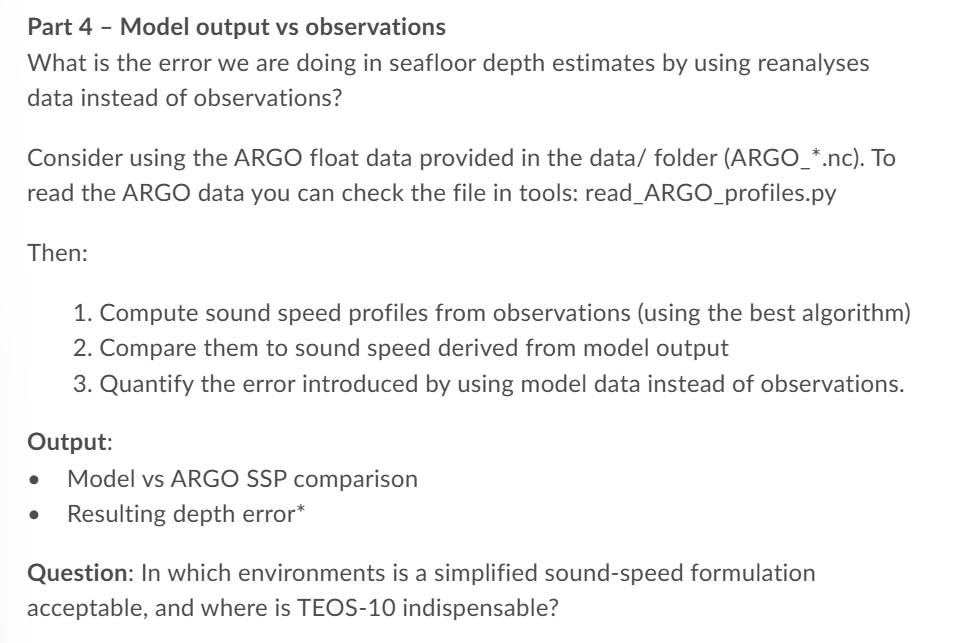